## PartA_Data structures and functions


In [26]:
# Load the periodic table into a pandas DataFrame.
import pandas as pd
df= pd.read_csv("periodic_table.csv") 

In [ ]:
# Dictionnary where the symbols of elements are the keys, and the values are the atmoic mass.
atomic_mass_dict=dict(zip(df["Symbol"],df["AtomicMass"]))

In [ ]:
def mass_calculator(formula:str):
    """
    Calculates the molar mass of a chemical formula without parentheses.

    Parameters
    ----------
    formula : str
        Chemical formula, for example "H2O" or "CH3O".

    Returns
    -------
    float
        Molar mass in g/mol, using the atomic masses provided by periodic_table.csv.

    Notes
    -----
    An index i moves one charecter by one of the given formula.
    If the character is lowercase, the function pairs it with the capital letter to obtain the full symbol.
    Numbers are taken as amount of times the element is present (1 if no number is written).
    Final vlaue obtianed by atomic mass multiplied by the number given.
    Parentheses and hydrate dot notation are not supported.
    """
    total_mass=0
    i = 0

    while i < len(formula):
        symbol = formula[i]
        i += 1

        if i < len(formula) and formula[i].islower():
            symbol += formula[i]
            i += 1

        number = ""
        while i < len(formula) and formula[i].isdigit():
            number += formula[i]
            i += 1

        if number != "":
            count = int(number)
        else:
            count = 1
        total_mass += atomic_mass_dict[symbol] * count

    return total_mass


In [ ]:
def mass_calculator(formula:str):
    """
    Calculates the molar mass of a formula, including parenthesized groups.

    Parameters
    ----------
    formula : str
        Chemical formula, for example "Ca(OH)2".

    Returns
    -------
    float
        Molar mass in g/mol, using the atomic masses in atomic_mass_dict.

    Notes
    -----
    The index i moves through the formula, identifying element symbols.
    When an opening parenthesis is found, the characters up to the closing parenthesis are stored in a branch.
    Calling mass_calculator(branch) recursively gives the mass of that group.
    Digits after an element or group give its multiplier (the multiplier is 1 if none is present). 
    The mass times this count is added to total_mass.
    Parentheses must be matched. Nested parentheses 
    Hydrate dot notation are not supported by this version.
    """
    total_mass=0
    i = 0

    while i < len(formula):
        symbol = formula[i]
        i += 1
        branch= ""

        if symbol == "(":
            while formula[i] != ")":
                branch += formula[i]
                i += 1
            i += 1    
            mass= mass_calculator(branch)
        else:
            if i < len(formula) and formula[i].islower():
                symbol += formula[i]
                i += 1

            mass = atomic_mass_dict[symbol]

        number = ""
        while i < len(formula) and formula[i].isdigit():
            number += formula[i]
            i += 1

        if number != "":
            count = int(number)
        else:
            count = 1

        total_mass += mass * count

    return total_mass

In [ ]:
def mass_calculator(formula:str):
    """
    Calculates the molar mass of a formula with groups and hydrate water.

    Parameters
    ----------
    formula : str
        Chemical formula, for example "Ca(OH)2" or "CuSO4.5H2O".

    Returns
    -------
    float
        Molar mass in g/mol, using the atomic masses in atomic_mass_dict.

    Notes
    -----
    Element symbols and parenthesized groups are read as in the previous version. 
    A recursive call calculates each group's mass, and digits after an element or group give its multiplier, defaulting to 1.
    When a period is found, the next character is read as the number of water molecules. 
    This count is multiplied by mass_calculator("H2O") and added to total_mass, which is then returned immediately.
    Hydrates must use a period and a single-digit water count, as in "CuSO4.5H2O". 
    The remaining text after the count is not checked, as the function supposes only coordinated water.
    Parentheses must be matched; nested parentheses are not supported.
    """
    total_mass=0
    i = 0

    while i < len(formula):
        symbol = formula[i]
        i += 1
        branch= ""

        if symbol == ".":
            water_number = int(formula[i])
            total_mass += water_number * mass_calculator("H2O")
            return total_mass

        if symbol == "(":
            while formula[i] != ")":
                branch += formula[i]
                i += 1
            i += 1    
            mass= mass_calculator(branch)
        else:
            if i < len(formula) and formula[i].islower():
                symbol += formula[i]
                i += 1

            mass = atomic_mass_dict[symbol]

        number = ""
        while i < len(formula) and formula[i].isdigit():
            number += formula[i]
            i += 1

        if number != "":
            count = int(number)
        else:
            count = 1

        total_mass += mass * count

    return total_mass

249.69100000000003


## Part B_Stoichiometry and reaction balancing

### 1. Reaction Balancer Function

In [ ]:
#type:ignore
import numpy as np

def balance_reaction(reactants: list, products: list) -> list:
    """
    Finds the stoichiometric coefficients that balance a chemical reaction.

    Parameters
    ----------
    reactants : list of str
        Reactant formulas, for example ["C3H8", "O2"].
    products : list of str
        Product formulas, for example ["H2O", "CO2"].

    Returns
    -------
    list of int
        Stoichiometric coefficients, ordered as reactants followed by products.

    Notes
    -----
    Chemical formulas must use correct capitalization, e.g. "Na", not "NA".
    Parentheses and hydrate dot notation are not supported.
    Stoichiometric coefficients, ordered as reactants followed by products.
    """
    molecules = reactants + products
    atom_count = []
    for molecule in molecules:
        atoms = {}
        i = 0
        while i < len(molecule):
            element = molecule[i]
            i += 1
            if i < len(molecule) and molecule[i].islower():
                element += molecule[i]
                i += 1
            number = ""
            while i < len(molecule) and molecule[i].isdigit():
                number += molecule[i]
                i += 1
            if number == "":
                count = 1
            else:
                count = int(number)
            if element in atoms:
                atoms[element] += count
            else:
                atoms[element] = count
        atom_count.append(atoms)

    elements = []
    for atoms in atom_count:
        for element in atoms:
            if element not in elements:
                elements.append(element)

    A = np.zeros((len(elements), len(molecules)))

    for i, element in enumerate(elements):
        for j, atoms in enumerate(atom_count):
            A[i, j] = atoms.get(element, 0)
            if j >= len(reactants):
                A[i, j] *= -1

    U, S, Vh = np.linalg.svd(A) #méthode SVD

    coefficients = Vh[-1]
    coefficients = coefficients / coefficients[0]

    return coefficients
    

print(balance_reaction(["C3H8", "O2"], ["H2O", "CO2"]))
print(balance_reaction(["KMnO4", "HCl"], ["KCl", "MnCl2", "Cl2", "H2O"]))
print(balance_reaction(["K2Cr2O7", "HCl"], ["KCl", "CrCl3", "Cl2", "H2O"]))










    


    


   

[1. 5. 4. 3.]
[1.  8.  1.  1.  2.5 4. ]
[ 1. 14.  2.  2.  3.  7.]


## Part C_Simulation /Modelling

### 1. Monte Carlo \pi estimate

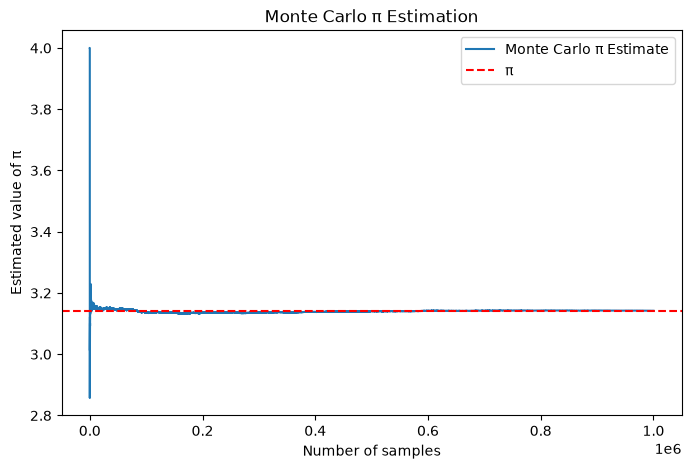

The value of pi estimated with N=1000000 is: 3.141944


In [2]:
#type:ignore
import numpy as np
import matplotlib.pyplot as plt 

def estimate_pi(N):
    x = np.random.uniform(-1, 1, N)
    y = np.random.uniform(-1, 1, N)

    distance = np.sqrt(x**2 + y**2)

    ins = distance <= 1

    pi_estimates = 4 * np.cumsum(ins) / np.arange(1, N + 1)

    
    pi_estimate = pi_estimates[-1]

    return pi_estimate, pi_estimates


N = 1000000

pi_value, pi_values = estimate_pi(N)


plt.figure(figsize=(8, 5))

plt.plot(
    range(1, N + 1),
    pi_values,
    label="Monte Carlo π Estimate"
)

plt.axhline(
    y=np.pi,
    color="red",
    linestyle="--",
    label="π"
)

plt.xlabel("Number of samples")
plt.ylabel("Estimated value of π")
plt.title("Monte Carlo π Estimation")
plt.legend()
plt.show()

print(f"The value of pi estimated with N={N} is: {pi_value}")


### 2. Chemistry inspired Monte Carlo

In [3]:

def simulate_collision(M, threshold):
    collision = np.arange(M)
    energie = np.random.uniform(0, 100, M)

    reacting_collision = np.sum(energie >= threshold)
    reaction_probability = reacting_collision/M

    return energie, reacting_collision, reaction_probability

M = 1000
threshold = 60

energie, reacting_collision, reaction_probability = simulate_collision(M, threshold)

print("Number of collisions occuring:", M)
print("Energie of each collision:", energie)
print("Number of collisions exceeding the threshold", reacting_collision)
print("Probability that a reaction occurs:", reaction_probability)






    

Number of collisions occuring: 1000
Energie of each collision: [2.31013776e+01 2.55655321e+01 8.25842980e+01 8.41941299e+01
 3.62023686e+01 9.00317260e+01 4.82046797e+01 5.40566611e+01
 6.63540196e+01 6.29203780e+01 1.01961275e+01 4.44813471e+01
 2.14438773e+01 6.33278341e+01 1.38433462e+01 6.53730202e+01
 8.14937567e+00 4.93181652e+00 8.64621598e+01 8.52130744e+00
 5.98891639e+01 9.98484811e+01 2.34779944e+01 5.48043558e+01
 5.65420808e+01 8.64496856e+01 8.60441424e+01 4.49811853e+01
 6.99856949e+01 4.15833636e+01 6.35773141e+01 4.95921254e+01
 3.62137935e+01 7.99205597e+01 4.63526059e+01 4.00070538e+01
 5.33777301e+01 8.53178350e+01 2.14904585e+01 9.45162270e+01
 3.57346863e+01 8.45242967e+01 4.77529528e+01 4.53955263e+01
 2.62786851e+00 2.29210719e+01 8.27708355e+01 6.68519358e+01
 7.45371341e+01 2.28578396e+01 2.24573462e+01 9.68468499e+01
 8.42658366e+00 5.79286627e+01 8.23849226e+01 3.70952401e+01
 2.24228740e+01 3.81304825e+01 6.17201996e+01 7.04389783e+01
 7.95400026e+01 2.1734